# Imports

In [30]:
pip install git+https://github.com/jpmedras/grouped_stratified_split

Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/jpmedras/grouped_stratified_split to /tmp/pip-req-build-2omrte3t
  Running command git clone --filter=blob:none --quiet https://github.com/jpmedras/grouped_stratified_split /tmp/pip-req-build-2omrte3t
  Resolved https://github.com/jpmedras/grouped_stratified_split to commit 992adf49fda79648ada14746a44e48ed2e66995f
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


In [31]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from priority_group_stratified_split import GroupSet, PrioritySplit

# Import dataset


In [32]:
# Assuming your file is in 'My Drive/your_folder/videos_info.csv'
# Replace 'your_folder' with the actual folder name
file_path = '../load_downsample/videos_info.csv'

try:
    df = pd.read_csv(file_path)
    print("File loaded successfully.")
    # Now you can work with the dataframe 'df'
    print(df.head()) # Example: print the first few rows
except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")


File loaded successfully.
   index             game_id       soundtrack                       segment  \
0      2  3-ninjas-kick-back  soundtrack_0001  3-ninjas-kick-back_00635.mp4   
1      3  3-ninjas-kick-back  soundtrack_0001  3-ninjas-kick-back_00671.mp4   
2     14  3-ninjas-kick-back  soundtrack_0002  3-ninjas-kick-back_00109.mp4   
3     24  3-ninjas-kick-back  soundtrack_0002  3-ninjas-kick-back_00345.mp4   
4     45  3-ninjas-kick-back  soundtrack_0003  3-ninjas-kick-back_00085.mp4   

      genre  
0  Platform  
1  Platform  
2  Platform  
3  Platform  
4  Platform  


# Exploring

In [33]:
df.shape

(53666, 5)

In [34]:
df.groupby(['game_id']).value_counts().groupby('genre').count()

genre
Action        6628
Adventure     2817
Fighting      6374
Platform      7063
Puzzle        3367
RPG           3819
Racing        5134
Shooters      7235
Simulation    2772
Sports        5813
Strategy      2644
Name: count, dtype: int64

In [35]:
df.groupby(['game_id', 'genre']).count()

,,index,soundtrack,segment
game_id,genre,,,
3-ninjas-kick-back,Platform,26,26,26
3x3-eyes-juuma-houkan,Fighting,70,70,70
3x3-eyes-seima-kourinden,Fighting,62,62,62
7th-saga-the,RPG,26,26,26
90-minutes-european-prime-goal,Sports,44,44,44
...,...,...,...,...
zenkoku-koukou-soccer-senshuken-96,Simulation,107,107,107
zero-the-kamikaze-squirrel,Platform,18,18,18
zombies-ate-my-neighbors,Action,60,60,60


# Plotting proportions

In [36]:
def get_proportions(group_set:GroupSet):
    proportions = []
    labels = []

    for label, l_groups in group_set.get_label_indexer().items():
        l_proportion = (l_groups.total_size/group_set.total_size)*100
        labels.append(label)
        proportions.append(l_proportion)

    labels_idx = [i for i in range(len(labels))]
    labels_idx.sort(key=lambda idx: labels[idx])
    labels.sort()


    # Sort proportion in labels alphabetic order
    ordered_proportions = [None for _ in range(len(proportions))]

    for i, label_i in (enumerate(labels_idx)):
        ordered_proportions[i] = proportions[label_i]

    return ordered_proportions, labels

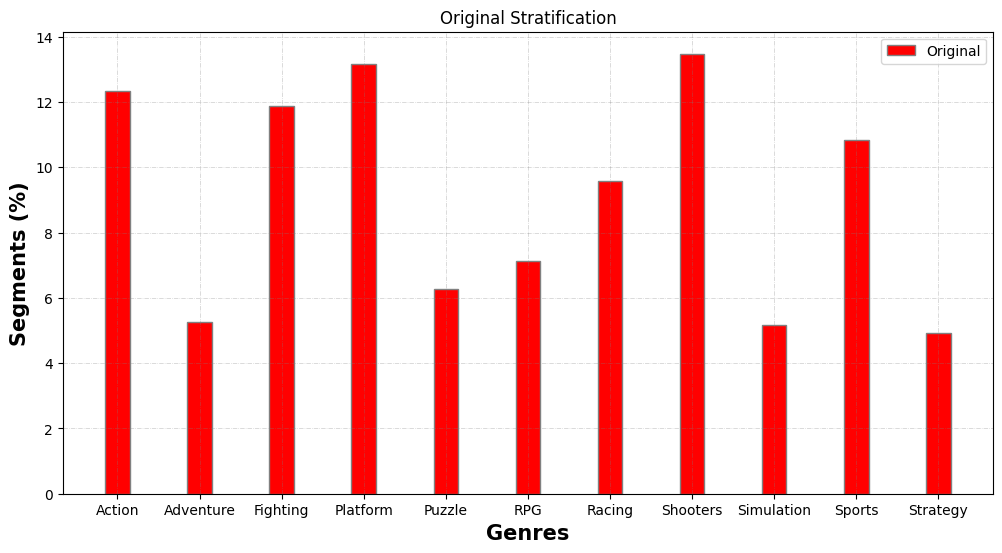

In [37]:
def plot_original_stratification(group_set:GroupSet):
    # set width of bar
    barWidth = 0.3
    fig, ax = plt.subplots(figsize =(12 , 6))

    # set height of bar
    orig_p, orig_l = get_proportions(groups)

    # Set position of bar on X axis
    br_orig = np.arange(len(orig_p))

    # Add x, y gridlines
    plt.grid(color ='grey', linestyle ='-.', linewidth = 0.5, alpha = 0.4)

    # Make the plot
    plt.bar(br_orig, orig_p, color ='r', width = barWidth, edgecolor ='grey', label ='Original')

    # Adding Xticks
    plt.xlabel('Genres', fontweight ='bold', fontsize = 15)
    plt.ylabel('Segments (%)', fontweight ='bold', fontsize = 15)
    plt.xticks([r for r in range(len(orig_p))], orig_l)
    plt.title("Original Stratification")

    plt.legend()
    plt.show()

groups = GroupSet.from_df(df, 'game_id', 'genre')
groups

plot_original_stratification(groups)

# Split

In [38]:
TRAIN = 0.8
EVAL =  0.1
TEST =  0.1

In [39]:
print('Total Size:', groups.total_size)
print('Expected Train Size:', round(groups.total_size * TRAIN))
print('Expected Eval:', round(groups.total_size * EVAL))
print('Expected Test Size:', round(groups.total_size * TEST))

Total Size: 53666
Expected Train Size: 42933
Expected Eval: 5367
Expected Test Size: 5367


In [40]:
priority_split = PrioritySplit()
train, eval, test = priority_split.get_split(groups, [TRAIN, EVAL, TEST])

print('Total Size:', train.total_size + eval.total_size + test.total_size)
print('Train Size:', train.total_size)
print('Eval Size:', eval.total_size)
print('Test Size:', test.total_size)

Total Size: 53666
Train Size: 43468
Eval Size: 5366
Test Size: 4832


In [41]:
df.set_index('game_id', inplace=True)

train_df = df[df.index.isin(train.get_uids())]
eval_df = df[df.index.isin(eval.get_uids())]
test_df = df[df.index.isin(test.get_uids())]

In [44]:
train_df.to_csv(os.path.join('train.csv'))
eval_df.to_csv(os.path.join('eval.csv'))
test_df.to_csv(os.path.join('test.csv'))

# Split quality

[5366.6, 5366.6, 42932.8]
[5366, 4832, 43468]


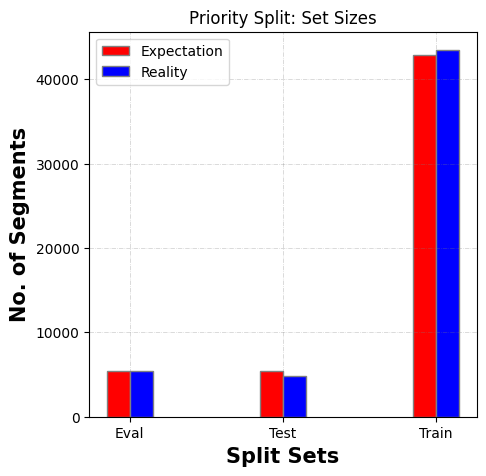

In [45]:
# set width of bar
barWidth = 0.15
fig, ax = plt.subplots(figsize =(5, 5))

# set height of bar
eval_expec, eval_real = groups.total_size * EVAL, eval.total_size
test_expec, test_real = groups.total_size * TEST, test.total_size
train_expec, train_real = groups.total_size * TRAIN, train.total_size

expec = [eval_expec, test_expec, train_expec]
real = [eval_real, test_real, train_real]

print(expec)
print(real)

# Set position of bar on X axis
br_expec = np.arange(len(expec))
br_real = [x + barWidth for x in br_expec]

# Add x, y gridlines
plt.grid(color ='grey',
        linestyle ='-.', linewidth = 0.5,
        alpha = 0.4)

# Make the plot
plt.bar(br_expec, expec, color ='r', width = barWidth,
        edgecolor ='grey', label ='Expectation')
plt.bar(br_real, real, color ='b', width = barWidth,
        edgecolor ='grey', label ='Reality')

# Adding Xticks
splits = ['Eval', 'Test', 'Train']
plt.xlabel('Split Sets', fontweight ='bold', fontsize = 15)
plt.ylabel('No. of Segments', fontweight ='bold', fontsize = 15)
plt.xticks([r + barWidth/2 for r in range(len(splits))], splits)
#plt.yticks([x*100 for x in range(25)])

plt.title("Priority Split: Set Sizes")

plt.legend()
plt.show()

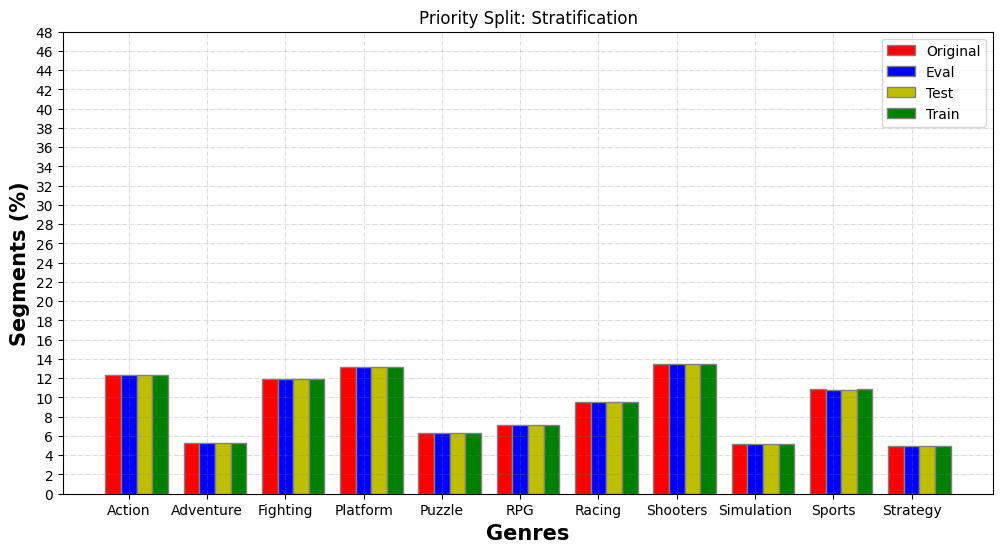

In [46]:
# set width of bar
barWidth = 0.2
fig, ax = plt.subplots(figsize =(12 , 6))

# set height of bar
orig_p, orig_l = get_proportions(groups)
eval_p, eval_l = get_proportions(eval)
test_p, test_l = get_proportions(test)
train_p, train_l = get_proportions(train)

# Set position of bar on X axis
br_orig = np.arange(len(orig_p))
br_eval = [x + barWidth for x in br_orig]
br_test = [x + barWidth for x in br_eval]
br_train = [x + barWidth for x in br_test]

# Add x, y gridlines
plt.grid(color ='grey',
        linestyle ='-.', linewidth = 0.5,
        alpha = 0.4)

# Make the plot
plt.bar(br_orig, orig_p, color ='r', width = barWidth,
        edgecolor ='grey', label ='Original')
plt.bar(br_eval, eval_p, color ='b', width = barWidth,
        edgecolor ='grey', label ='Eval')
plt.bar(br_test, test_p, color ='y', width = barWidth,
        edgecolor ='grey', label ='Test')
plt.bar(br_train, train_p, color ='g', width = barWidth,
        edgecolor ='grey', label ='Train')


# Adding Xticks
plt.xlabel('Genres', fontweight ='bold', fontsize = 15)
plt.ylabel('Segments (%)', fontweight ='bold', fontsize = 15)
plt.xticks([r + barWidth for r in range(len(orig_p))], orig_l)
plt.yticks([x*2 for x in range(25)])
plt.title("Priority Split: Stratification")

plt.legend()
plt.show()